# 01 — Exploratory Data Analysis (IEEE-CIS Fraud Detection)

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
except NameError:
    ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
sys.path.insert(0, ROOT)
os.makedirs(os.path.join(ROOT, "outputs"), exist_ok=True)

sns.set_theme(style="whitegrid")
DATA_DIR = os.path.join(ROOT, "data", "raw")

In [2]:
transactions = pd.read_csv(os.path.join(DATA_DIR, "train_transaction.csv"))
identity = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))
print(f"Transactions: {transactions.shape}")
print(f"Identity: {identity.shape}")
print(f"Fraud rate: {transactions['isFraud'].mean():.4%}")

Transactions: (590540, 394)
Identity: (144233, 41)
Fraud rate: 3.4990%


In [3]:
display_cols = ["TransactionAmt", "isFraud", "ProductCD", "card4", "TransactionDT"]
display(transactions[display_cols].head(10))

,TransactionAmt,isFraud,ProductCD,card4,TransactionDT
0,68.5,0,W,discover,86400
1,29.0,0,W,mastercard,86401
2,59.0,0,W,visa,86469
3,50.0,0,W,mastercard,86499
4,50.0,0,H,mastercard,86506
5,49.0,0,W,visa,86510
6,159.0,0,W,visa,86522
7,422.5,0,W,visa,86529
8,15.0,0,H,visa,86535
9,117.0,0,W,mastercard,86536


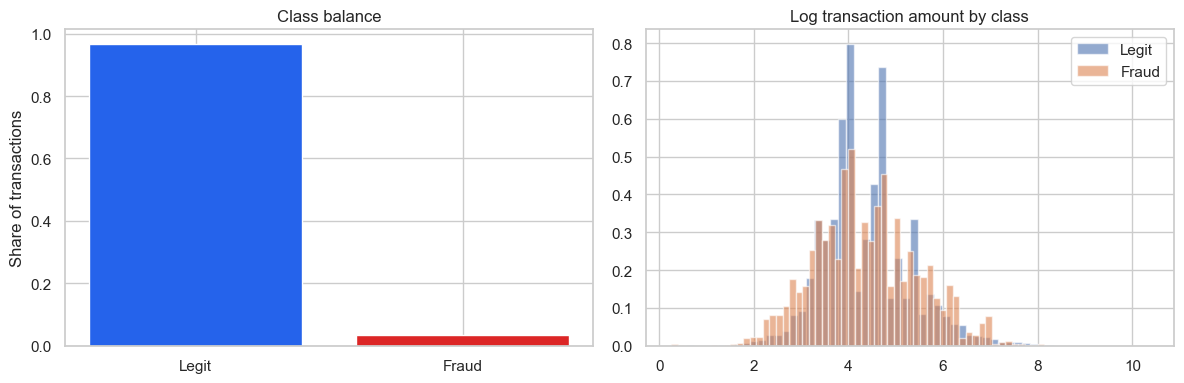

Saved C:\Users\Lenovo\OneDrive\github_projects\fraud-detection-ml\outputs\eda_class_balance_amount.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fraud_rate = transactions["isFraud"].mean()
axes[0].bar(["Legit", "Fraud"], [1 - fraud_rate, fraud_rate], color=["#2563EB", "#DC2626"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("Share of transactions")

log_amt = np.log1p(transactions["TransactionAmt"])
axes[1].hist(log_amt[transactions["isFraud"] == 0], bins=60, alpha=0.6, label="Legit", density=True)
axes[1].hist(log_amt[transactions["isFraud"] == 1], bins=60, alpha=0.6, label="Fraud", density=True)
axes[1].set_title("Log transaction amount by class")
axes[1].legend()
plt.tight_layout()
out = os.path.join(ROOT, "outputs", "eda_class_balance_amount.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

,fraud_rate,n
ProductCD,,
C,0.116873,68519
S,0.058996,11628
H,0.047662,33024
R,0.037826,37699
W,0.020399,439670


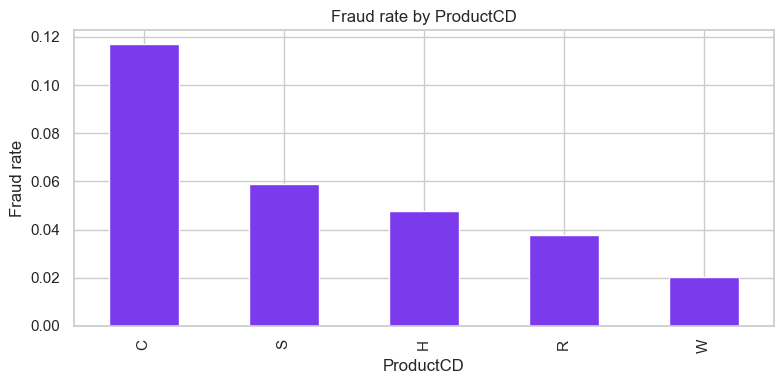

Saved C:\Users\Lenovo\OneDrive\github_projects\fraud-detection-ml\outputs\eda_fraud_rate_by_product.png


In [5]:
if "ProductCD" in transactions.columns:
    fraud_by_product = (
        transactions.groupby("ProductCD")["isFraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "n"})
        .sort_values("fraud_rate", ascending=False)
    )
    display(fraud_by_product.head(10))

    fig, ax = plt.subplots(figsize=(8, 4))
    fraud_by_product["fraud_rate"].plot(kind="bar", ax=ax, color="#7C3AED")
    ax.set_title("Fraud rate by ProductCD")
    ax.set_ylabel("Fraud rate")
    plt.tight_layout()
    out = os.path.join(ROOT, "outputs", "eda_fraud_rate_by_product.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")

In [6]:
merged = transactions.merge(identity, on="TransactionID", how="left", indicator=True)
coverage = merged["_merge"].value_counts(normalize=True)
print("Identity join coverage:")
print(coverage)
display(coverage.to_frame("share"))

Identity join coverage:
_merge
left_only     0.755761
both          0.244239
right_only    0.000000
Name: proportion, dtype: float64


,share
_merge,
left_only,0.755761
both,0.244239
right_only,0.000000
